# Classifier behaviour under feature selection

How each classifier responds as the number of selected features `k` grows, and how
much of its score comes from the selection method rather than from the data itself.

Every number here is produced by `scripts/run_experiment.py`, which runs the
(selector x k x classifier x fold) grid with the selector fit inside each fold.
This notebook only reads `results/` and draws; it fits nothing.

The `random` selector is the control: it picks `k` features without looking at the
data, so the vertical distance between the two lines is what the selection method
actually contributed.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RESULTS = ROOT / 'results'
FIGURES = ROOT / 'figures'
FIGURES.mkdir(exist_ok=True)

scores = pd.read_csv(RESULTS / 'scores.csv')
raw = pd.read_csv(RESULTS / 'scores_raw.csv')
stability = pd.read_csv(RESULTS / 'stability.csv')

print(f"{raw.shape[0]} fold-level rows, "
      f"{scores.selector.nunique()} selectors, "
      f"{scores.classifier.nunique()} classifiers, "
      f"k in {sorted(scores.k.unique())}")
scores.head()

350 fold-level rows, 2 selectors, 5 classifiers, k in [np.int64(10), np.int64(25), np.int64(50), np.int64(100), np.int64(250), np.int64(500), np.int64(1000)]


,selector,k,classifier,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,balanced_accuracy_mean,balanced_accuracy_std,mcc_mean,mcc_std,selection_time_s_mean,selection_time_s_std,selection_peak_mb_mean,selection_peak_mb_std,classifier_fit_time_s_mean,classifier_fit_time_s_std,n_selected_mean,n_selected_std
0,anova_f,10,knn,0.744214,0.020796,0.706336,0.033002,0.686514,0.037203,0.609227,0.034262,0.367065,0.0115,434.588054,0.063149,0.004345,0.001292,10.0,0.0
1,anova_f,10,lda_shrinkage,0.766054,0.013574,0.727808,0.020527,0.695625,0.024503,0.642312,0.021049,0.367065,0.0115,434.588054,0.063149,0.009347,0.000227,10.0,0.0
2,anova_f,10,linear_svm,0.750733,0.008792,0.620374,0.012288,0.619675,0.015253,0.616644,0.015082,0.367065,0.0115,434.588054,0.063149,0.018765,0.003013,10.0,0.0
3,anova_f,10,logistic_regression,0.766378,0.010477,0.735741,0.013870,0.711879,0.020186,0.643600,0.018041,0.367065,0.0115,434.588054,0.063149,0.027866,0.004505,10.0,0.0
4,anova_f,10,random_forest,0.777775,0.005362,0.757385,0.013812,0.735212,0.017807,0.662445,0.008016,0.367065,0.0115,434.588054,0.063149,1.213250,0.248803,10.0,0.0


In [2]:
# Categorical hues in fixed order, so a selector keeps its colour in every figure.
SERIES = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300']
SURFACE, INK, INK_MUTED = '#fcfcfb', '#0b0b0b', '#52514e'

SELECTORS = sorted(scores.selector.unique())
COLOR = {name: SERIES[i] for i, name in enumerate(SELECTORS)}
CONTROL = 'random'

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'axes.edgecolor': '#d6d5d1', 'axes.labelcolor': INK_MUTED,
    'text.color': INK, 'xtick.color': INK_MUTED, 'ytick.color': INK_MUTED,
    'axes.spines.top': False, 'axes.spines.right': False,
    'grid.color': '#eceae6', 'axes.grid': True, 'grid.linewidth': 0.8,
    'font.size': 10, 'axes.titlesize': 11, 'legend.frameon': False,
    'lines.linewidth': 2, 'lines.markersize': 5,
})


def panels(classifiers, ncols=3, height=3.0):
    """One panel per classifier, shared axes, unused panels removed.

    Returns the used axes plus the bottom-most axis of each column, which are
    the only ones that keep tick labels once the axes are shared.
    """
    n = len(classifiers)
    nrows = -(-n // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, height * nrows),
                             sharex=True, sharey=True)
    axes = axes.ravel()
    for ax in axes[n:]:
        ax.remove()
    used = axes[:n]
    bottom = [used[max(i for i in range(n) if i % ncols == col)]
              for col in range(min(ncols, n))]
    for ax in bottom:
        ax.tick_params(labelbottom=True)
    return fig, used, bottom


CLASSIFIERS = sorted(scores.classifier.unique())
print(CLASSIFIERS)

['knn', 'lda_shrinkage', 'linear_svm', 'logistic_regression', 'random_forest']


## 1. Macro-F1 against k, one panel per classifier

Macro-F1 rather than accuracy because the PAM50 classes are imbalanced: LumA is
1540 samples and Normal is 202, so accuracy rewards ignoring the rare subtypes.

`k` is on a log axis because it was swept geometrically (10 to 1000).

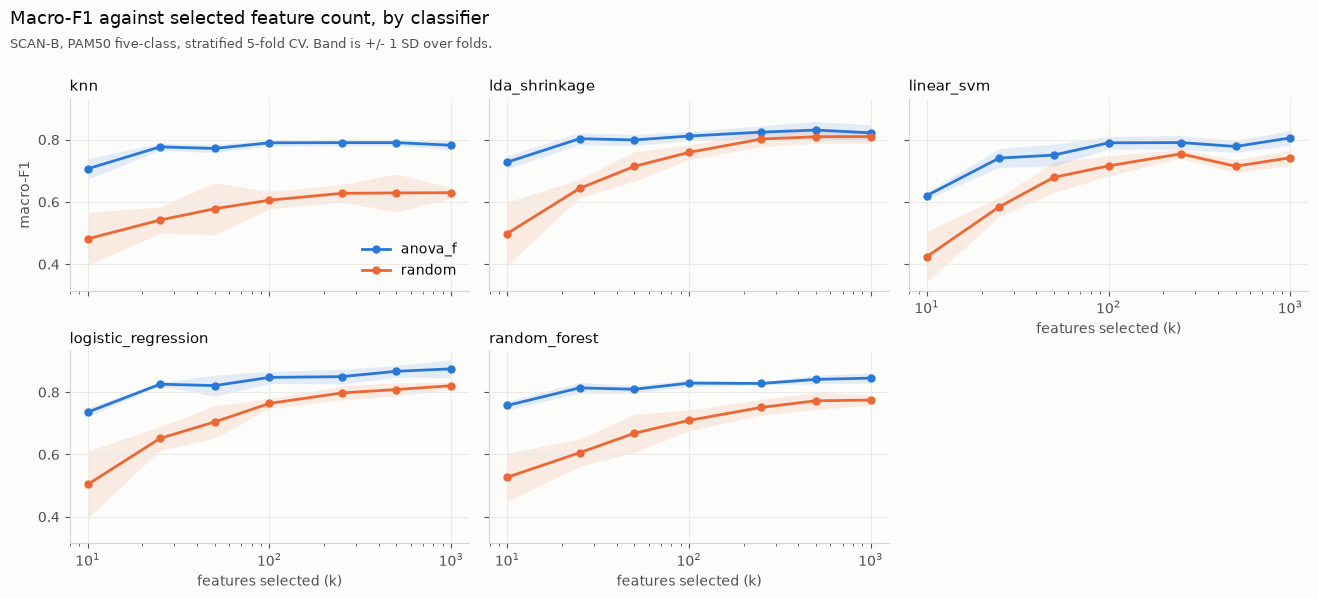

In [3]:
fig, axes, bottom_axes = panels(CLASSIFIERS)

for ax, clf in zip(axes, CLASSIFIERS):
    sub = scores[scores.classifier == clf]
    for sel in SELECTORS:
        s = sub[sub.selector == sel].sort_values('k')
        ax.plot(s.k, s.macro_f1_mean, marker='o', color=COLOR[sel], label=sel)
        ax.fill_between(s.k, s.macro_f1_mean - s.macro_f1_std,
                        s.macro_f1_mean + s.macro_f1_std,
                        color=COLOR[sel], alpha=0.12, linewidth=0)
    ax.set_xscale('log')
    ax.set_title(clf, loc='left')

for ax in bottom_axes:
    ax.set_xlabel('features selected (k)')
axes[0].set_ylabel('macro-F1')
axes[0].legend(loc='lower right')

fig.tight_layout(rect=[0, 0, 1, 0.90])
fig.suptitle('Macro-F1 against selected feature count, by classifier',
             x=0.005, y=0.99, ha='left', fontsize=13)
fig.text(0.005, 0.945, 'SCAN-B, PAM50 five-class, stratified 5-fold CV. '
         'Band is +/- 1 SD over folds.', ha='left', va='top',
         color=INK_MUTED, fontsize=9)
fig.savefig(FIGURES / 'macro_f1_vs_k.png', dpi=200, bbox_inches='tight')

## 2. What the selection method contributed

The same data as a difference from the control: `macro-F1(selector) - macro-F1(random)`
at the same k and classifier. Zero means the method did no better than picking
features blindly.

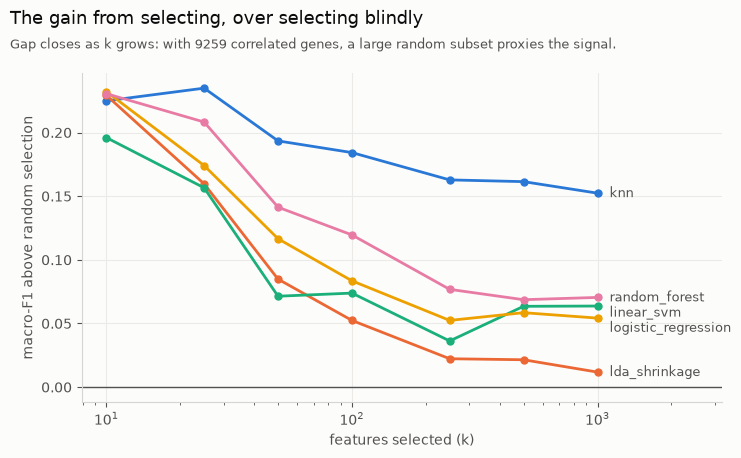

In [4]:
wide = scores.pivot_table(index=['classifier', 'k'], columns='selector',
                          values='macro_f1_mean')
gap = wide.drop(columns=CONTROL).sub(wide[CONTROL], axis=0).reset_index()

fig, ax = plt.subplots(figsize=(7.5, 4.6))
informative = [c for c in SELECTORS if c != CONTROL]

ends = []
for i, clf in enumerate(CLASSIFIERS):
    s = gap[gap.classifier == clf].sort_values('k')
    for sel in informative:
        ax.plot(s.k, s[sel], marker='o', color=SERIES[i % len(SERIES)],
                label=clf if sel == informative[0] else None)
        ends.append((s[sel].iloc[-1], s.k.iloc[-1], f'{clf}', SERIES[i % len(SERIES)]))

# Direct labels instead of a legend box, nudged apart where lines end close
# together so no two labels overlap.
span = max(e[0] for e in ends) - min(e[0] for e in ends)
min_gap = span * 0.085
placed = []
for y, x, text, color in sorted(ends, reverse=True):
    if placed and placed[-1] - y < min_gap:
        y_label = placed[-1] - min_gap
    else:
        y_label = y
    placed.append(y_label)
    ax.annotate(text, xy=(x, y), xytext=(x * 1.12, y_label), textcoords='data',
                va='center', fontsize=9, color=INK_MUTED, annotation_clip=False)

ax.axhline(0, color=INK_MUTED, linewidth=1)
ax.set_xscale('log')
ax.set_xlabel('features selected (k)')
ax.set_ylabel('macro-F1 above random selection')
ax.set_xlim(right=gap.k.max() * 3.2)
fig.tight_layout(rect=[0, 0, 1, 0.88])
fig.text(0.005, 0.985, 'The gain from selecting, over selecting blindly',
         ha='left', va='top', fontsize=13, color=INK)
fig.text(0.005, 0.925, 'Gap closes as k grows: with 9259 correlated genes, a large '
         'random subset proxies the signal.', ha='left', va='top',
         color=INK_MUTED, fontsize=9)
fig.savefig(FIGURES / 'gain_over_random.png', dpi=200, bbox_inches='tight')

## 3. Selection stability

Kuncheva's consistency index over the five folds, chance-corrected so that a
selector picking at random scores 0 rather than the positive overlap you get by
luck. It does not depend on the classifier: it asks whether the method names the
same genes when the training data shifts slightly.

A method that scores well but is unstable is a weak scientific result, because the
gene list it produces is an artefact of the split.

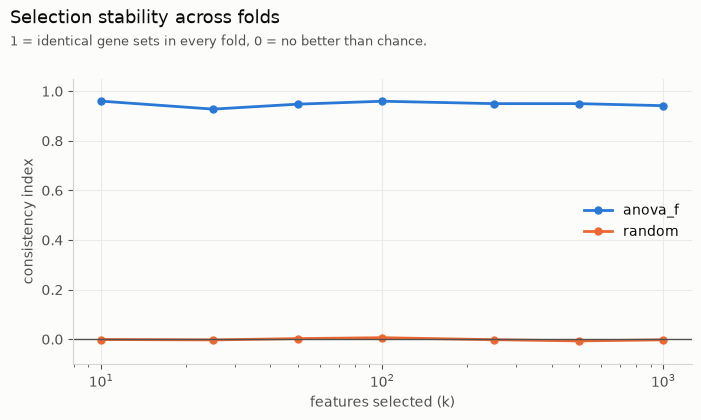

In [5]:
fig, ax = plt.subplots(figsize=(7.0, 4.2))

for sel in SELECTORS:
    s = stability[stability.selector == sel].sort_values('k')
    ax.plot(s.k, s.consistency_index, marker='o', color=COLOR[sel], label=sel)

ax.axhline(0, color=INK_MUTED, linewidth=1)
ax.set_xscale('log')
ax.set_ylim(-0.1, 1.05)
ax.set_xlabel('features selected (k)')
ax.set_ylabel('consistency index')
ax.legend(loc='center right')
fig.tight_layout(rect=[0, 0, 1, 0.86])
fig.text(0.005, 0.99, 'Selection stability across folds',
         ha='left', va='top', fontsize=13, color=INK)
fig.text(0.005, 0.93, '1 = identical gene sets in every fold, 0 = no better than chance.',
         ha='left', va='top', color=INK_MUTED, fontsize=9)
fig.savefig(FIGURES / 'selection_stability.png', dpi=200, bbox_inches='tight')

## 4. What selection costs

Runtime and peak memory of the selector alone, excluding classifier training.
This is the axis the parallel infrastructure has to move, so it is reported next
to accuracy rather than as an afterthought.

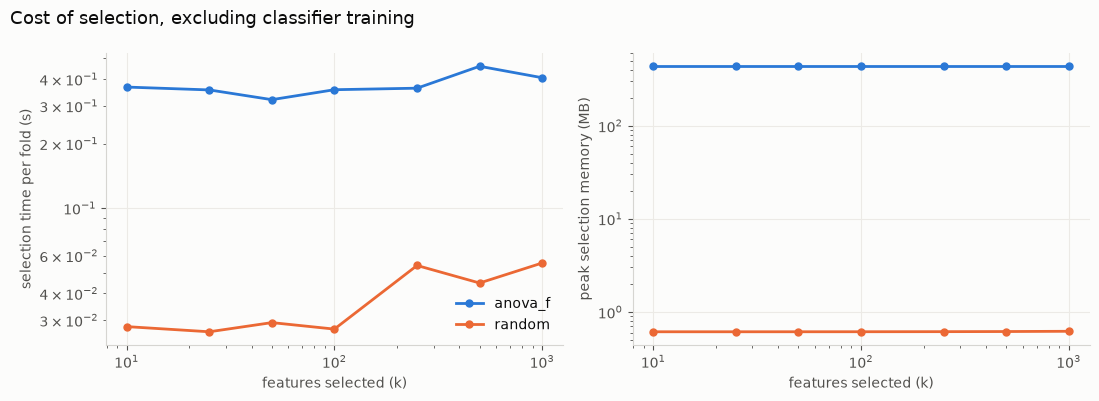

In [6]:
cost = (scores.groupby(['selector', 'k'])[['selection_time_s_mean', 'selection_peak_mb_mean']]
        .mean().reset_index())

fig, (ax_t, ax_m) = plt.subplots(1, 2, figsize=(11, 4.0))

for sel in SELECTORS:
    s = cost[cost.selector == sel].sort_values('k')
    ax_t.plot(s.k, s.selection_time_s_mean, marker='o', color=COLOR[sel], label=sel)
    ax_m.plot(s.k, s.selection_peak_mb_mean, marker='o', color=COLOR[sel], label=sel)

for ax, label in ((ax_t, 'selection time per fold (s)'),
                  (ax_m, 'peak selection memory (MB)')):
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('features selected (k)')
    ax.set_ylabel(label)
ax_t.legend(loc='best')

fig.tight_layout(rect=[0, 0, 1, 0.92])
fig.suptitle('Cost of selection, excluding classifier training',
             x=0.005, y=0.99, ha='left', fontsize=13)
fig.savefig(FIGURES / 'selection_cost.png', dpi=200, bbox_inches='tight')

## 5. Per-classifier reading

The table below is what each panel says in numbers: where the classifier peaks,
how much it gains over the control at its best k, and how much of the curve is
flat. A classifier whose gain collapses at large k is one that handles redundant
features on its own; a classifier that keeps gaining needs the selector.

In [7]:
rows = []
for clf in CLASSIFIERS:
    for sel in [s for s in SELECTORS if s != CONTROL]:
        s = scores[(scores.classifier == clf) & (scores.selector == sel)]
        best = s.loc[s.macro_f1_mean.idxmax()]
        g = gap[gap.classifier == clf].set_index('k')[sel]
        rows.append({
            'classifier': clf,
            'selector': sel,
            'best_k': int(best.k),
            'best_macro_f1': round(best.macro_f1_mean, 4),
            'sd_over_folds': round(best.macro_f1_std, 4),
            'gain_at_best_k': round(g.loc[best.k], 4),
            'gain_at_k10': round(g.loc[g.index.min()], 4),
            'gain_at_max_k': round(g.loc[g.index.max()], 4),
        })

summary = pd.DataFrame(rows).sort_values(['selector', 'best_macro_f1'], ascending=[True, False])
summary.to_csv(RESULTS / 'per_classifier_summary.csv', index=False)
summary

,classifier,selector,best_k,best_macro_f1,sd_over_folds,gain_at_best_k,gain_at_k10,gain_at_max_k
3,logistic_regression,anova_f,1000,0.8749,0.0278,0.0542,0.2321,0.0542
4,random_forest,anova_f,1000,0.8450,0.0165,0.0705,0.2305,0.0705
1,lda_shrinkage,anova_f,500,0.8307,0.0275,0.0215,0.2292,0.0118
2,linear_svm,anova_f,1000,0.8055,0.0241,0.0637,0.1960,0.0637
0,knn,anova_f,250,0.7903,0.0111,0.1628,0.2249,0.1524


In [8]:
# Where each classifier peaks, and how flat it is beyond that point.
for clf in CLASSIFIERS:
    s = scores[(scores.classifier == clf) & (scores.selector != CONTROL)]
    best = s.loc[s.macro_f1_mean.idxmax()]
    tail = s[s.k > best.k].macro_f1_mean
    decay = best.macro_f1_mean - tail.min() if len(tail) else 0.0
    print(f"{clf:>20}: peaks at k={int(best.k):>4} "
          f"(macro-F1 {best.macro_f1_mean:.4f}), "
          f"loses {decay:.4f} beyond it")

                 knn: peaks at k= 250 (macro-F1 0.7903), loses 0.0083 beyond it
       lda_shrinkage: peaks at k= 500 (macro-F1 0.8307), loses 0.0091 beyond it
          linear_svm: peaks at k=1000 (macro-F1 0.8055), loses 0.0000 beyond it
 logistic_regression: peaks at k=1000 (macro-F1 0.8749), loses 0.0000 beyond it
       random_forest: peaks at k=1000 (macro-F1 0.8450), loses 0.0000 beyond it
